<a href="https://colab.research.google.com/github/rodrigoeduardo9/LosLederesSemana7/blob/main/LosLederesSemana7_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Programa de Perceptrón Simple desde cero para lógica AND/OR

class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=10):
        # Inicializamos los pesos en cero (para 2 entradas)
        self.weights = [0.0, 0.0]
        self.bias = 0.0
        self.learning_rate = learning_rate
        self.epochs = epochs

    def activation_function(self, x):
        # Función escalón: retorna 1 si x >= 0, de lo contrario 0
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        # Cálculo de la suma ponderada: (w1*x1 + w2*x2) + bias
        summation = sum(w * i for w, i in zip(self.weights, inputs)) + self.bias
        return self.activation_function(summation)

    def train(self, training_inputs, labels):
        for _ in range(self.epochs):
            for inputs, label in zip(training_inputs, labels):
                prediction = self.predict(inputs)
                # Cálculo del error
                error = label - prediction
                # Ajuste de pesos: w = w + lr * error * input
                self.weights[0] += self.learning_rate * error * inputs[0]
                self.weights[1] += self.learning_rate * error * inputs[1]
                # Ajuste del bias: b = b + lr * error
                self.bias += self.learning_rate * error

def main():
    print("--- Perceptrón Simple desde Cero ---")
    print("1. Lógica AND")
    print("2. Lógica OR")

    opcion = input("Elige el tipo de lógica (1 o 2): ")

    # Definimos las entradas de la tabla de verdad (las 4 combinaciones)
    entradas = [[0, 0], [0, 1], [1, 0], [1, 1]]
    salidas_esperadas = []

    if opcion == '1':
        print("\nHas seleccionado lógica AND")
        salidas_esperadas = [0, 0, 0, 1]
    else:
        print("\nHas seleccionado lógica OR")
        salidas_esperadas = [1 if sum(x) > 0 else 0 for x in entradas]
        # Corrección manual para asegurar consistencia
        salidas_esperadas = [0, 1, 1, 1]

    print("\n--- Entrenamiento ---")
    model = Perceptron()
    model.train(entradas, salidas_esperadas)

    print(f"Pesos finales: {model.weights}")
    print(f"Bias final: {model.bias}")

    print("\n--- Resultados Finales ---")
    for i, inputs in enumerate(entradas):
        pred = model.predict(inputs)
        print(f"Entrada: {inputs} | Real: {salidas_esperadas[i]} | Predicho: {pred}")

    print("\n--- Prueba Manual ---")
    try:
        x1 = int(input("Ingresa valor para X1 (0 o 1): "))
        x2 = int(input("Ingresa valor para X2 (0 o 1): "))
        resultado = model.predict([x1, x2])
        print(f"El resultado predicho para [{x1}, {x2}] es: {resultado}")
    except ValueError:
        print("Por favor ingresa solo números (0 o 1).")

if __name__ == "__main__":
    main()

--- Perceptrón Simple desde Cero ---
1. Lógica AND
2. Lógica OR
Elige el tipo de lógica (1 o 2): 1

Has seleccionado lógica AND

--- Entrenamiento ---
Pesos finales: [0.2, 0.1]
Bias final: -0.20000000000000004

--- Resultados Finales ---
Entrada: [0, 0] | Real: 0 | Predicho: 0
Entrada: [0, 1] | Real: 0 | Predicho: 0
Entrada: [1, 0] | Real: 0 | Predicho: 0
Entrada: [1, 1] | Real: 1 | Predicho: 1

--- Prueba Manual ---
Ingresa valor para X1 (0 o 1): 0
Ingresa valor para X2 (0 o 1): 0
El resultado predicho para [0, 0] es: 0


In [2]:
# Demostración: El Perceptrón Simple no puede resolver la lógica XOR

class PerceptronXOR:
    def __init__(self, learning_rate=0.1, epochs=20):
        # Inicializamos pesos aleatorios o en cero
        self.weights = [0.1, -0.2]
        self.bias = 0.05
        self.learning_rate = learning_rate
        self.epochs = epochs

    def activation(self, x):
        # Función escalón: 1 si x >= 0, sino 0
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        # Suma ponderada + bias
        summation = sum(w * i for w, i in zip(self.weights, inputs)) + self.bias
        return self.activation(summation)

    def train(self, training_data, labels):
        print(f"Iniciando entrenamiento por {self.epochs} épocas...\n")
        for epoch in range(1, self.epochs + 1):
            total_error = 0
            for inputs, label in zip(training_data, labels):
                prediction = self.predict(inputs)
                error = label - prediction
                total_error += abs(error)

                # Actualización de pesos y bias
                self.weights[0] += self.learning_rate * error * inputs[0]
                self.weights[1] += self.learning_rate * error * inputs[1]
                self.bias += self.learning_rate * error

            if epoch % 5 == 0 or epoch == 1:
                print(f"Época {epoch}: Pesos={self.weights}, Bias={self.bias:.4f}, Errores en esta época={total_error}")

def main():
    # Dataset XOR: No es linealmente separable
    # (0,0) -> 0
    # (0,1) -> 1
    # (1,0) -> 1
    # (1,1) -> 0
    entradas = [[0, 0], [0, 1], [1, 0], [1, 1]]
    salidas_reales = [0, 1, 1, 0]

    print("--- Intento de resolver XOR con un Perceptrón Simple ---")
    modelo = PerceptronXOR(learning_rate=0.2, epochs=50)
    modelo.train(entradas, salidas_reales)

    print("\n--- Resultados Finales ---")
    exitos = 0
    for i, inputs in enumerate(entradas):
        pred = modelo.predict(inputs)
        es_correcto = "Correcto" if pred == salidas_reales[i] else "FALLO"
        if pred == salidas_reales[i]: exitos += 1
        print(f"Entrada: {inputs} | Real: {salidas_reales[i]} | Predicho: {pred} -> {es_correcto}")

    print(f"\nPrecisión final: {exitos/4 * 100}%")

    # EXPLICACIÓN TÉCNICA:
    print("\n============================================================")
    print("¿POR QUÉ FALLÓ EL PERCEPTRÓN?")
    print("1. El Perceptrón simple solo puede aprender problemas 'Linealmente Separables'.")
    print("2. Esto significa que el modelo intenta dibujar una línea recta para separar los 0 de los 1.")
    print("3. En XOR, es imposible separar los resultados con una sola línea recta.")
    print("4. Para resolver XOR, necesitamos una Red Neuronal Multicapa (MLP) con al menos")
    print("   una capa oculta, que permite crear fronteras de decisión no lineales.")
    print("============================================================")

if __name__ == "__main__":
    main()

--- Intento de resolver XOR con un Perceptrón Simple ---
Iniciando entrenamiento por 50 épocas...

Época 1: Pesos=[-0.1, -0.2], Bias=-0.1500, Errores en esta época=3
Época 5: Pesos=[-0.1, -0.2], Bias=0.0500, Errores en esta época=4
Época 10: Pesos=[-0.1, -0.2], Bias=0.0500, Errores en esta época=4
Época 15: Pesos=[-0.1, -0.2], Bias=0.0500, Errores en esta época=4
Época 20: Pesos=[-0.1, -0.2], Bias=0.0500, Errores en esta época=4
Época 25: Pesos=[-0.1, -0.2], Bias=0.0500, Errores en esta época=4
Época 30: Pesos=[-0.1, -0.2], Bias=0.0500, Errores en esta época=4
Época 35: Pesos=[-0.1, -0.2], Bias=0.0500, Errores en esta época=4
Época 40: Pesos=[-0.1, -0.2], Bias=0.0500, Errores en esta época=4
Época 45: Pesos=[-0.1, -0.2], Bias=0.0500, Errores en esta época=4
Época 50: Pesos=[-0.1, -0.2], Bias=0.0500, Errores en esta época=4

--- Resultados Finales ---
Entrada: [0, 0] | Real: 0 | Predicho: 1 -> FALLO
Entrada: [0, 1] | Real: 1 | Predicho: 0 -> FALLO
Entrada: [1, 0] | Real: 1 | Predicho: 0

Época 0 | Error: 1.0474
Época 2000 | Error: 0.0221
Época 4000 | Error: 0.0055
Época 6000 | Error: 0.0030
Época 8000 | Error: 0.0021
Época 10000 | Error: 0.0016
Época 12000 | Error: 0.0013
Época 14000 | Error: 0.0011

--- Pesos Finales ---
W Capa Oculta: [[-6.447308046373005, 4.7464114727304665], [-6.621260758125001, 4.7797043002338295]]
B Capa Oculta: [2.5914648180783573, -7.402668188509601]

--- Predicciones Finales ---
X: [0, 0] | Real: 0 | Pred: 0.0142 -> 0
X: [0, 1] | Real: 1 | Pred: 0.9838 -> 1
X: [1, 0] | Real: 1 | Pred: 0.9836 -> 1
X: [1, 1] | Real: 0 | Pred: 0.0155 -> 0


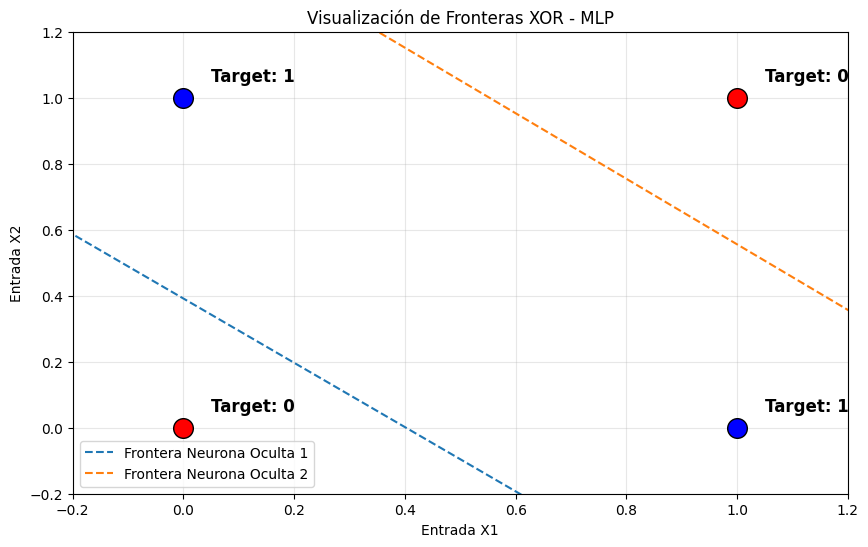


--- Prueba Manual ---
Error en entrada.


In [5]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np

# --- EXPLICACIÓN CONCEPTUAL ---
# Un perceptrón simple solo puede trazar una línea recta.
# XOR requiere separar puntos que no son linealmente separables.
# Al usar 2 neuronas en la capa oculta, cada una genera su propia línea (frontera de decisión).
# La neurona de salida combina estas dos líneas para crear una región de clasificación compleja.

class MLP_Visualizer:
    def __init__(self, lr=0.5, epochs=10000):
        self.lr = lr
        self.epochs = epochs

        # Pesos y Bias (2 entradas -> 2 neuronas ocultas -> 1 salida)
        # W_hidden: [entrada1, entrada2] x [neurona1, neurona2]
        self.W1 = [[random.uniform(-1, 1), random.uniform(-1, 1)],
                   [random.uniform(-1, 1), random.uniform(-1, 1)]]
        self.B1 = [random.uniform(-1, 1), random.uniform(-1, 1)]

        # W_output: [salida_h1, salida_h2] x [neurona_salida]
        self.W2 = [random.uniform(-1, 1), random.uniform(-1, 1)]
        self.B2 = random.uniform(-1, 1)

    def sigmoid(self, x):
        # Usamos sigmoide: su rango (0,1) es ideal para lógica binaria y permite derivar fácilmente
        return 1 / (1 + math.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        # Capa oculta
        self.h_in = []
        self.h_out = []
        for i in range(2):
            val = X[0] * self.W1[0][i] + X[1] * self.W1[1][i] + self.B1[i]
            self.h_out.append(self.sigmoid(val))

        # Capa salida
        self.out_in = self.h_out[0] * self.W2[0] + self.h_out[1] * self.W2[1] + self.B2
        self.output = self.sigmoid(self.out_in)
        return self.output

    def train(self, data, targets):
        for epoch in range(self.epochs):
            error_total = 0
            for x, y in zip(data, targets):
                # Forward
                pred = self.forward(x)
                error = y - pred
                error_total += error**2

                # Backpropagation
                d_out = error * self.sigmoid_derivative(pred)

                d_hidden = []
                for i in range(2):
                    d_h = d_out * self.W2[i] * self.sigmoid_derivative(self.h_out[i])
                    d_hidden.append(d_h)

                # Actualizar pesos salida
                for i in range(2):
                    self.W2[i] += self.lr * d_out * self.h_out[i]
                self.B2 += self.lr * d_out

                # Actualizar pesos ocultos
                for i in range(2): # neurona
                    for j in range(2): # entrada
                        self.W1[j][i] += self.lr * d_hidden[i] * x[j]
                    self.B1[i] += self.lr * d_hidden[i]

            if epoch % 2000 == 0:
                print(f"Época {epoch} | Error: {error_total:.4f}")

    def plot_decision_boundaries(self, data, targets):
        plt.figure(figsize=(10, 6))

        # Crear malla para el fondo de decisión
        x_range = np.linspace(-0.5, 1.5, 100)
        y_range = np.linspace(-0.5, 1.5, 100)
        xx, yy = np.meshgrid(x_range, y_range)

        # Graficar fronteras de las neuronas individuales de la capa oculta
        # La línea se define donde W1*X + B1 = 0
        for i in range(2):
            # Despejamos x2: x2 = -(W1[0]*x1 + B) / W1[1]
            if self.W1[1][i] != 0:
                line_y = -(np.array(x_range) * self.W1[0][i] + self.B1[i]) / self.W1[1][i]
                plt.plot(x_range, line_y, '--', label=f'Frontera Neurona Oculta {i+1}')

        # Colorear puntos reales
        for x, y in zip(data, targets):
            color = 'red' if y == 0 else 'blue'
            plt.scatter(x[0], x[1], c=color, s=200, edgecolors='k', zorder=5)
            plt.text(x[0]+0.05, x[1]+0.05, f'Target: {y}', fontsize=12, fontweight='bold')

        plt.title("Visualización de Fronteras XOR - MLP")
        plt.xlabel("Entrada X1")
        plt.ylabel("Entrada X2")
        plt.xlim(-0.2, 1.2)
        plt.ylim(-0.2, 1.2)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

def main():
    X = [[0, 0], [0, 1], [1, 0], [1, 1]]
    Y = [0, 1, 1, 0]

    model = MLP_Visualizer(lr=0.4, epochs=15001)
    model.train(X, Y)

    print("\n--- Pesos Finales ---")
    print(f"W Capa Oculta: {model.W1}")
    print(f"B Capa Oculta: {model.B1}")

    print("\n--- Predicciones Finales ---")
    for x, y in zip(X, Y):
        p = model.forward(x)
        print(f"X: {x} | Real: {y} | Pred: {p:.4f} -> {round(p)}")

    model.plot_decision_boundaries(X, Y)

    print("\n--- Prueba Manual ---")
    try:
        x1 = float(input("Ingresa X1 (0 o 1): "))
        x2 = float(input("Ingresa X2 (0 o 1): "))
        res = model.forward([x1, x2])
        print(f"Resultado del modelo: {res:.4f} (Clase: {round(res)})")
    except:
        print("Error en entrada.")

if __name__ == "__main__":
    main()

--- Resultados XOR ---
Entrada: [0 0] | Real: 0 | Pred: 0 (0.0099)
Entrada: [0 1] | Real: 1 | Pred: 1 (0.9882)
Entrada: [1 0] | Real: 1 | Pred: 0 (0.4998)
Entrada: [1 1] | Real: 0 | Pred: 1 (0.5003)

--- Métricas de Evaluación ---
Matriz de Confusión: [[1, 1], [1, 1]]
Accuracy:  0.50
Precision: 0.50
Recall:    0.50
F1-Score:  0.50


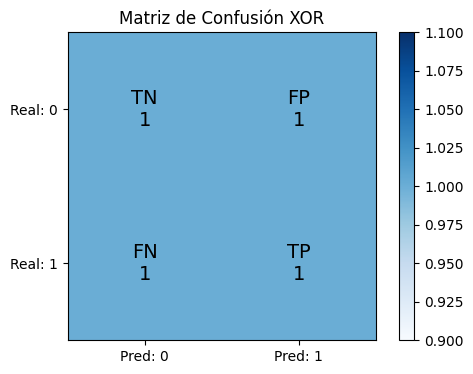

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- EXPLICACIÓN DEL MODELO ---
# Para resolver XOR necesitamos una capa oculta.
# Evaluaremos el rendimiento usando una Matriz de Confusión calculada manualmente.

class MLP_Evaluator:
    def __init__(self, lr=0.5, epochs=10000):
        self.lr = lr
        self.epochs = epochs
        # Inicialización de pesos usando Numpy para mayor eficiencia
        # Capa entrada (2) -> Capa oculta (2)
        self.W1 = np.random.uniform(size=(2, 2))
        self.B1 = np.random.uniform(size=(1, 2))
        # Capa oculta (2) -> Salida (1)
        self.W2 = np.random.uniform(size=(2, 1))
        self.B2 = np.random.uniform(size=(1, 1))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def train(self, X, y):
        for epoch in range(self.epochs):
            # Forward Propagation
            hidden_layer_input = np.dot(X, self.W1) + self.B1
            hidden_layer_output = self.sigmoid(hidden_layer_input)

            output_layer_input = np.dot(hidden_layer_output, self.W2) + self.B2
            predicted_output = self.sigmoid(output_layer_input)

            # Backpropagation
            error = y - predicted_output
            d_predicted_output = error * self.sigmoid_derivative(predicted_output)

            error_hidden_layer = d_predicted_output.dot(self.W2.T)
            d_hidden_layer = error_hidden_layer * self.sigmoid_derivative(hidden_layer_output)

            # Actualización de Pesos y Bias
            self.W2 += hidden_layer_output.T.dot(d_predicted_output) * self.lr
            self.B2 += np.sum(d_predicted_output, axis=0, keepdims=True) * self.lr
            self.W1 += X.T.dot(d_hidden_layer) * self.lr
            self.B1 += np.sum(d_hidden_layer, axis=0, keepdims=True) * self.lr

    def predict(self, X):
        h = self.sigmoid(np.dot(X, self.W1) + self.B1)
        o = self.sigmoid(np.dot(h, self.W2) + self.B2)
        return o

def main():
    # Dataset XOR
    X = np.array([[0,0], [0,1], [1,0], [1,1]])
    Y = np.array([[0], [1], [1], [0]])

    # Crear y Entrenar
    model = MLP_Evaluator(lr=0.5, epochs=20000)
    model.train(X, Y)

    # Predicciones finales
    raw_preds = model.predict(X)
    bin_preds = [1 if p >= 0.5 else 0 for p in raw_preds]
    targets = Y.flatten()

    print("--- Resultados XOR ---")
    for i in range(len(X)):
        print(f"Entrada: {X[i]} | Real: {targets[i]} | Pred: {bin_preds[i]} ({raw_preds[i][0]:.4f})")

    # --- CÁLCULO MANUAL DE MATRIZ DE CONFUSIÓN ---
    TP, TN, FP, FN = 0, 0, 0, 0
    for r, p in zip(targets, bin_preds):
        if r == 1 and p == 1: TP += 1
        elif r == 0 and p == 0: TN += 1
        elif r == 0 and p == 1: FP += 1
        elif r == 1 and p == 0: FN += 1

    confusion_matrix = [[TN, FP], [FN, TP]]

    # --- MÉTRICAS ---
    accuracy = (TP + TN) / len(targets)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print("\n--- Métricas de Evaluación ---")
    print(f"Matriz de Confusión: {confusion_matrix}")
    print(f"Accuracy:  {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1-Score:  {f1:.2f}")

    # --- VISUALIZACIÓN ---
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(confusion_matrix, cmap='Blues')

    # Etiquetas
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: 0', 'Pred: 1'])
    ax.set_yticklabels(['Real: 0', 'Real: 1'])
    ax.set_title("Matriz de Confusión XOR")

    # Anotaciones de texto
    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{confusion_matrix[i][j]}",
                    ha="center", va="center", color="black", fontsize=14)

    plt.colorbar(im)
    plt.show()

if __name__ == "__main__":
    main()